In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
from xgboost import XGBRegressor

from comorbidipy import comorbidity, ScoreType, MappingVariant, WeightingVariant
from polars import from_pandas
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option('display.max_columns', None)

In [2]:
gt_ip = pd.read_csv('../data/processed/ehn_gt_inpatient_20251223000.csv')
gt_op = pd.read_csv('../data/processed/ehn_gt_outpatient_20251223000.csv')
risks = pd.read_csv('../data/processed/2024 Totals and Risk.csv')

/var/folders/v8/s4lwxw8s6wxbkhy0gqkmypnc0000gn/T/ipykernel_51430/615313613.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  risks = pd.read_csv('../data/processed/2024 Totals and Risk.csv')


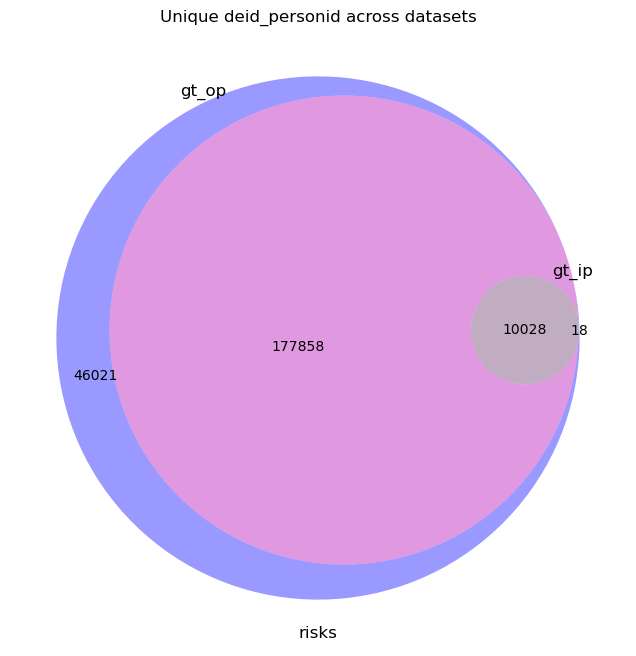

In [3]:
from matplotlib_venn import venn3

import matplotlib.pyplot as plt

# Get unique deid_personid from each dataframe
op_ids = set(gt_op.deid_personid.unique())
ip_ids = set(gt_ip.deid_personid.unique())
risk_ids = set(risks.deid_personid.unique())

# Create Venn diagram
plt.figure(figsize=(10, 8))
venn3([op_ids, ip_ids, risk_ids], set_labels=('gt_op', 'gt_ip', 'risks'))
plt.title('Unique deid_personid across datasets')
plt.show()

## Date Handling

In [ ]:
# -----------------------------------------
# COPY DATAFRAMES 
# -----------------------------------------
gt_ip = gt_ip.copy()
gt_op = gt_op.copy()
risks = risks.copy()

# -----------------------------------------
# DEFINE DATE COLUMNS
# -----------------------------------------
ip_date_col = "admitdate"   
op_date_col = "eventdate"     

# -----------------------------------------
# CONVERT TO DATETIME
# -----------------------------------------
gt_ip[ip_date_col] = pd.to_datetime(gt_ip[ip_date_col], errors="coerce")
gt_op[op_date_col] = pd.to_datetime(gt_op[op_date_col], errors="coerce")

# -----------------------------------------
# DEFINE STUDY YEAR AND SPLIT
# -----------------------------------------
study_year = 2024
cutoff_date = pd.Timestamp(f"{study_year}-06-30")
start_date = pd.Timestamp(f"{study_year}-01-01")
end_date = pd.Timestamp(f"{study_year}-12-31")

print("Study year:", study_year)
print("Cutoff date:", cutoff_date)

Study year: 2024
Cutoff date: 2024-06-30 00:00:00


## Keep only claims in the study year

In [5]:
# -----------------------------------------
# RESTRICT CLAIMS TO STUDY YEAR
# -----------------------------------------
gt_ip = gt_ip[
    gt_ip[ip_date_col].between(start_date, end_date, inclusive="both")
].copy()

gt_op = gt_op[
    gt_op[op_date_col].between(start_date, end_date, inclusive="both")
].copy()

print("IP rows in study year:", len(gt_ip))
print("OP rows in study year:", len(gt_op))

IP rows in study year: 14437
OP rows in study year: 3572469


## Split claims into first half and second half

In [6]:
# -----------------------------------------
# FIRST HALF = FEATURES
# SECOND HALF = OUTCOME WINDOW
# -----------------------------------------
gt_ip_first = gt_ip[gt_ip[ip_date_col] <= cutoff_date].copy()
gt_ip_second = gt_ip[gt_ip[ip_date_col] > cutoff_date].copy()

gt_op_first = gt_op[gt_op[op_date_col] <= cutoff_date].copy()
gt_op_second = gt_op[gt_op[op_date_col] > cutoff_date].copy()

print("IP first-half rows:", len(gt_ip_first))
print("IP second-half rows:", len(gt_ip_second))
print("OP first-half rows:", len(gt_op_first))
print("OP second-half rows:", len(gt_op_second))

IP first-half rows: 6805
IP second-half rows: 7632
OP first-half rows: 1716496
OP second-half rows: 1855973


## Standardize ICD codes

In [7]:
# -----------------------------------------
# STANDARDIZE ICD CODES
# -----------------------------------------
gt_ip_first["primary_icd"] = (
    gt_ip_first["primary_icd"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.upper()
)

gt_ip_second["primary_icd"] = (
    gt_ip_second["primary_icd"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.upper()
)

gt_op_first["primary_icd"] = (
    gt_op_first["primary_icd"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.upper()
)

gt_op_second["primary_icd"] = (
    gt_op_second["primary_icd"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.upper()
)

## Load and clean CCSR crosswalk

In [8]:
# -----------------------------------------
# LOAD CCSR CROSSWALK
# -----------------------------------------
ccsr = pd.read_csv("../data/raw/DXCCSR_v2026-1.csv")

ccsr.columns = ccsr.columns.astype(str).str.strip("'\"")

ccsr["icd10cm_code_std"] = (
    ccsr["ICD-10-CM CODE"]
    .astype(str)
    .str.strip("'\"")
    .str.replace(".", "", regex=False)
    .str.upper()
)

/var/folders/v8/s4lwxw8s6wxbkhy0gqkmypnc0000gn/T/ipykernel_51430/1627118178.py:4: DtypeWarning: Columns (15,17) have mixed types. Specify dtype option on import or set low_memory=False.
  ccsr = pd.read_csv("../data/raw/DXCCSR_v2026-1.csv")


## Merge CCSR onto first-half claims only

In [9]:
# -----------------------------------------
# MERGE CCSR TO FIRST-HALF IP CLAIMS
# -----------------------------------------
gt_ip_first = gt_ip_first.merge(
    ccsr[
        [
            "icd10cm_code_std",
            "Default CCSR CATEGORY IP",
            "Default CCSR CATEGORY DESCRIPTION IP"
        ]
    ],
    left_on="primary_icd",
    right_on="icd10cm_code_std",
    how="left"
)

# -----------------------------------------
# MERGE CCSR TO FIRST-HALF OP CLAIMS
# -----------------------------------------
gt_op_first = gt_op_first.merge(
    ccsr[
        [
            "icd10cm_code_std",
            "Default CCSR CATEGORY OP",
            "Default CCSR CATEGORY DESCRIPTION OP"
        ]
    ],
    left_on="primary_icd",
    right_on="icd10cm_code_std",
    how="left"
)

##  Create second-half target cost per member

In [10]:
# -----------------------------------------
# SECOND-HALF COST OUTCOME
# Sum IP + OP cost in Jul-Dec
# -----------------------------------------
ip_cost_second = (
    gt_ip_second.groupby("deid_personid", as_index=False)["cost"]
    .sum()
    .rename(columns={"cost": "ip_cost_second_half"})
)

op_cost_second = (
    gt_op_second.groupby("deid_personid", as_index=False)["cost"]
    .sum()
    .rename(columns={"cost": "op_cost_second_half"})
)

target_cost = pd.merge(
    ip_cost_second,
    op_cost_second,
    on="deid_personid",
    how="outer"
).fillna(0)

target_cost["costtotal_second_half"] = (
    target_cost["ip_cost_second_half"] +
    target_cost["op_cost_second_half"]
)

target_cost = target_cost[["deid_personid", "costtotal_second_half"]]
target_cost.head()

,deid_personid,costtotal_second_half
0,00005c8c0136e5d1e49f50700c83ccf7,2839.15
1,0000672cf36fc1586ff74101e9ee3d6e,2572.46
2,00006961e0cd7e393b6075560382cfd4,3045.54
3,0000e6a86c13982bddcaab914d3d127b,619.56
4,0000e96e2625f9ff3cff108d1a079afe,383.67


## Approximate second-half PMPM

In [11]:
# -----------------------------------------
# APPROXIMATE SECOND-HALF MEMBER MONTHS
# If annual membermonths exists, use min(membermonths, 6)
# -----------------------------------------
target_base = risks[["deid_personid", "membermonths"]].drop_duplicates().copy()

target_base = target_base.merge(target_cost, on="deid_personid", how="left")
target_base["costtotal_second_half"] = target_base["costtotal_second_half"].fillna(0)

target_base["membermonths_second_half"] = np.minimum(
    target_base["membermonths"].fillna(0),
    6
)

target_base["costtotal_second_half_mm"] = np.where(
    target_base["membermonths_second_half"] > 0,
    target_base["costtotal_second_half"] / target_base["membermonths_second_half"],
    np.nan
)

target_base[["costtotal_second_half", "membermonths_second_half", "costtotal_second_half_mm"]].describe()

,costtotal_second_half,membermonths_second_half,costtotal_second_half_mm
count,2.339250e+05,233925.000000,233925.000000
mean,3.718168e+03,5.413556,833.737951
std,1.727875e+04,1.295440,5029.982351
min,0.000000e+00,1.000000,0.000000
25%,0.000000e+00,6.000000,0.000000
50%,5.603800e+02,6.000000,105.753333
75%,2.061920e+03,6.000000,411.233333
max,2.006734e+06,6.000000,684199.290000


## Build first-half utilization features from claims

In [12]:
# -----------------------------------------
# FIRST-HALF IP COUNT
# -----------------------------------------
ip_count_first = (
    gt_ip_first.groupby("deid_personid")
    .size()
    .reset_index(name="countip_first_half")
)

# -----------------------------------------
# FIRST-HALF OP COUNT
# -----------------------------------------
op_count_first = (
    gt_op_first.groupby("deid_personid")
    .size()
    .reset_index(name="countop_first_half")
)

# -----------------------------------------
# FIRST-HALF TOTAL IP COST
# -----------------------------------------
ip_cost_first = (
    gt_ip_first.groupby("deid_personid", as_index=False)["cost"]
    .sum()
    .rename(columns={"cost": "ip_cost_first_half"})
)

# -----------------------------------------
# FIRST-HALF TOTAL OP COST
# -----------------------------------------
op_cost_first = (
    gt_op_first.groupby("deid_personid", as_index=False)["cost"]
    .sum()
    .rename(columns={"cost": "op_cost_first_half"})
)

## Build first-half recency features

In [13]:
# -----------------------------------------
# DAYS SINCE LAST IP VISIT (relative to cutoff)
# -----------------------------------------
ip_last_date = (
    gt_ip_first.groupby("deid_personid", as_index=False)[ip_date_col]
    .max()
    .rename(columns={ip_date_col: "last_ip_date"})
)

ip_last_date["days_since_last_ip"] = (
    cutoff_date - ip_last_date["last_ip_date"]
).dt.days

# -----------------------------------------
# DAYS SINCE LAST OP VISIT
# -----------------------------------------
op_last_date = (
    gt_op_first.groupby("deid_personid", as_index=False)[op_date_col]
    .max()
    .rename(columns={op_date_col: "last_op_date"})
)

op_last_date["days_since_last_op"] = (
    cutoff_date - op_last_date["last_op_date"]
).dt.days

## First-half comorbidity score

In [14]:
# -----------------------------------------
# CHARLSON FROM FIRST-HALF OP CLAIMS
# -----------------------------------------
comorbidity_op = comorbidity(
    from_pandas(gt_op_first[["deid_personid", "primary_icd"]]),
    id_col="deid_personid",
    code_col="primary_icd",
    score=ScoreType.CHARLSON,
    variant=MappingVariant.QUAN,
    weighting=WeightingVariant.CHARLSON,
)

# -----------------------------------------
# CHARLSON FROM FIRST-HALF IP CLAIMS
# -----------------------------------------
comorbidity_ip = comorbidity(
    from_pandas(gt_ip_first[["deid_personid", "primary_icd"]]),
    id_col="deid_personid",
    code_col="primary_icd",
    score=ScoreType.CHARLSON,
    variant=MappingVariant.QUAN,
    weighting=WeightingVariant.CHARLSON,
)

result_op = comorbidity_op.to_pandas()
result_ip = comorbidity_ip.to_pandas()

result = pd.merge(
    result_op,
    result_ip,
    on="deid_personid",
    how="outer",
    suffixes=("_op", "_ip")
)

result["comorbidity_score_first_half"] = (
    result[["comorbidity_score_op", "comorbidity_score_ip"]]
    .max(axis=1)
    .fillna(0)
    .astype(int)
)

result = result[["deid_personid", "comorbidity_score_first_half"]]

## Create first-half CCSR top-category flags

In [15]:
# -----------------------------------------
# START FROM MEMBERS WITH TARGET + RISKS INFO
# -----------------------------------------
model_df = target_base.merge(
    risks.drop_duplicates(subset=["deid_personid"]),
    on=["deid_personid", "membermonths"],
    how="left"
)

# Keep only members with valid target PMPM
model_df = model_df[model_df["costtotal_second_half_mm"].notna()].copy()

# -----------------------------------------
# TRAIN/TEST MEMBER SPLIT
# -----------------------------------------
member_ids = model_df["deid_personid"].drop_duplicates()

train_ids, test_ids = train_test_split(
    member_ids,
    test_size=0.2,
    random_state=42
)

train_ids = set(train_ids)
test_ids = set(test_ids)

# Split first-half claims by train/test members
gt_ip_first_train = gt_ip_first[gt_ip_first["deid_personid"].isin(train_ids)].copy()
gt_ip_first_test = gt_ip_first[gt_ip_first["deid_personid"].isin(test_ids)].copy()

gt_op_first_train = gt_op_first[gt_op_first["deid_personid"].isin(train_ids)].copy()
gt_op_first_test = gt_op_first[gt_op_first["deid_personid"].isin(test_ids)].copy()

## Top inpatient CCSR groups from first-half training claims only

In [16]:
# -----------------------------------------
# TOP 20 FIRST-HALF IP CCSR CATEGORIES
# TRAIN MEMBERS ONLY
# -----------------------------------------
top_ccsr_ip_cost_train = (
    gt_ip_first_train.dropna(
        subset=[
            "Default CCSR CATEGORY IP",
            "Default CCSR CATEGORY DESCRIPTION IP"
        ]
    )
    .groupby(
        ["Default CCSR CATEGORY IP", "Default CCSR CATEGORY DESCRIPTION IP"],
        as_index=False
    )["cost"]
    .sum()
    .rename(columns={"cost": "total_cost"})
    .sort_values("total_cost", ascending=False)
    .head(20)
)

top_ip_categories = top_ccsr_ip_cost_train["Default CCSR CATEGORY IP"].tolist()

train_top_ip_ids = set(
    gt_ip_first_train.loc[
        gt_ip_first_train["Default CCSR CATEGORY IP"].isin(top_ip_categories),
        "deid_personid"
    ].unique()
)

test_top_ip_ids = set(
    gt_ip_first_test.loc[
        gt_ip_first_test["Default CCSR CATEGORY IP"].isin(top_ip_categories),
        "deid_personid"
    ].unique()
)

## Top outpatient CCSR groups from first-half training claims only

In [18]:
# -----------------------------------------
# TOP 20 FIRST-HALF OP CCSR CATEGORIES
# TRAIN MEMBERS ONLY
# -----------------------------------------
top_ccsr_op_cost_train = (
    gt_op_first_train.dropna(
        subset=[
            "Default CCSR CATEGORY OP",
            "Default CCSR CATEGORY DESCRIPTION OP"
        ]
    )
    .groupby(
        ["Default CCSR CATEGORY OP", "Default CCSR CATEGORY DESCRIPTION OP"],
        as_index=False
    )["cost"]
    .sum()
    .rename(columns={"cost": "total_cost"})
    .sort_values("total_cost", ascending=False)
    .head(20)
)

top_op_categories = top_ccsr_op_cost_train["Default CCSR CATEGORY OP"].tolist()

train_top_op_ids = set(
    gt_op_first_train.loc[
        gt_op_first_train["Default CCSR CATEGORY OP"].isin(top_op_categories),
        "deid_personid"
    ].unique()
)

test_top_op_ids = set(
    gt_op_first_test.loc[
        gt_op_first_test["Default CCSR CATEGORY OP"].isin(top_op_categories),
        "deid_personid"
    ].unique()
)

## Merge all first-half engineered features into model frame

In [19]:
# -----------------------------------------
# MERGE FIRST-HALF FEATURES
# -----------------------------------------
feature_df = model_df[["deid_personid", "costtotal_second_half_mm"]].copy()

# Merge claims-based first-half features
for df in [
    ip_count_first,
    op_count_first,
    ip_cost_first,
    op_cost_first,
    ip_last_date[["deid_personid", "days_since_last_ip"]],
    op_last_date[["deid_personid", "days_since_last_op"]],
    result
]:
    feature_df = feature_df.merge(df, on="deid_personid", how="left")

# Merge chronic flags / annual fields from risks
risk_feature_cols = [
    "deid_personid",
    "chronicconditionasthmaind",
    "chronicconditionesrdind",
    "chronicconditionhfind",
    "chronicconditioncrfind",
    "chronicconditionhypertensionind",
    "chronicconditioncancerind",
    "chronicconditioncopdind",
    "chronicconditiondiabetesind",
    "riskhcctotalrisk"
]

feature_df = feature_df.merge(
    risks[risk_feature_cols].drop_duplicates(subset=["deid_personid"]),
    on="deid_personid",
    how="left"
)

## Add train-defined top CCSR flags

In [20]:
# -----------------------------------------
# ADD TRAIN-DEFINED CCSR FLAGS
# -----------------------------------------
feature_df["in_top_ip_ccsr_category_first_half"] = np.where(
    feature_df["deid_personid"].isin(train_top_ip_ids.union(test_top_ip_ids)),
    0,
    0
)

feature_df.loc[
    feature_df["deid_personid"].isin(train_top_ip_ids),
    "in_top_ip_ccsr_category_first_half"
] = 1

feature_df.loc[
    feature_df["deid_personid"].isin(test_top_ip_ids),
    "in_top_ip_ccsr_category_first_half"
] = 1

feature_df["in_top_op_ccsr_category_first_half"] = np.where(
    feature_df["deid_personid"].isin(train_top_op_ids.union(test_top_op_ids)),
    0,
    0
)

feature_df.loc[
    feature_df["deid_personid"].isin(train_top_op_ids),
    "in_top_op_ccsr_category_first_half"
] = 1

feature_df.loc[
    feature_df["deid_personid"].isin(test_top_op_ids),
    "in_top_op_ccsr_category_first_half"
] = 1

## Final train/test split at member level

In [31]:
# -----------------------------------------
# SPLIT FINAL MODEL DATA
# -----------------------------------------
train_df = feature_df[feature_df["deid_personid"].isin(train_ids)].copy()
test_df = feature_df[feature_df["deid_personid"].isin(test_ids)].copy()

feature_cols = [
    "chronicconditionasthmaind",
    "chronicconditionesrdind",
    "chronicconditionhfind",
    "chronicconditioncrfind",
    "chronicconditionhypertensionind",
    "chronicconditioncancerind",
    "chronicconditioncopdind",
    "chronicconditiondiabetesind",
    # "riskhcctotalrisk",
    "countip_first_half",
    "countop_first_half",
    "ip_cost_first_half",
    "op_cost_first_half",
    "days_since_last_ip",
    "days_since_last_op",
    "comorbidity_score_first_half",
    "in_top_ip_ccsr_category_first_half",
    "in_top_op_ccsr_category_first_half"
]

X_train = train_df[feature_cols].copy().fillna(0)
X_test = test_df[feature_cols].copy().fillna(0)

# Use log-transformed second-half PMPM as outcome
y_train = np.log1p(train_df["costtotal_second_half_mm"].astype(float))
y_test = np.log1p(test_df["costtotal_second_half_mm"].astype(float))

## Correlation and VIF

In [32]:
corr = X_train.corr()
corr

vif_df = pd.DataFrame({
    "feature": X_train.columns,
    "vif": [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
}).sort_values("vif", ascending=False)

vif_df

,feature,vif
8,countip_first_half,2.718615
16,in_top_op_ccsr_category_first_half,2.668457
9,countop_first_half,2.365736
4,chronicconditionhypertensionind,2.191060
14,comorbidity_score_first_half,1.950250
12,days_since_last_ip,1.916490
15,in_top_ip_ccsr_category_first_half,1.684688
7,chronicconditiondiabetesind,1.594693
3,chronicconditioncrfind,1.509000
13,days_since_last_op,1.435401


## Baseline model

In [33]:
baseline_pred = np.repeat(y_train.mean(), len(y_test))

baseline_results = {
    "baseline_rmse": root_mean_squared_error(y_test, baseline_pred),
    "baseline_r2": r2_score(y_test, baseline_pred)
}

baseline_results

{'baseline_rmse': 2.872259061158646, 'baseline_r2': -6.229160908000075e-05}

## Train models

In [34]:
results = {}

# -----------------------
# Decision Tree
# -----------------------
dt = DecisionTreeRegressor(
    random_state=42,
    max_depth=6,
    min_samples_leaf=50
)
dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

results["decision_tree_rmse"] = root_mean_squared_error(y_test, dt_pred)
results["decision_tree_r2"] = r2_score(y_test, dt_pred)

# -----------------------
# Random Forest
# -----------------------
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

results["random_forest_rmse"] = root_mean_squared_error(y_test, rf_pred)
results["random_forest_r2"] = r2_score(y_test, rf_pred)

# -----------------------
# XGBoost
# -----------------------
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

results["xgb_rmse"] = root_mean_squared_error(y_test, xgb_pred)
results["xgb_r2"] = r2_score(y_test, xgb_pred)

results

{'decision_tree_rmse': 2.224321203123173,
 'decision_tree_r2': 0.4002436716216411,
 'random_forest_rmse': 2.2756414771582594,
 'random_forest_r2': 0.3722488493651763,
 'xgb_rmse': 2.194548123272506,
 'xgb_r2': 0.41619198485274955}

## Calibration table for XGBoost

In [42]:
# -----------------------------------------
# BACK-TRANSFORM TO DOLLARS
# -----------------------------------------
y_test_dollars = np.expm1(y_test)
xgb_pred_dollars = np.expm1(xgb_pred)

df_eval_xgb = pd.DataFrame({
    "actual_cost": y_test_dollars,
    "predicted_cost": xgb_pred_dollars
})

# -----------------------------------------
# UPDATED BINS (UP TO 2500+)
# -----------------------------------------
bins = [
    0, 250, 500, 750, 1000, 1500, 2000, 2500,
    3000, 4000, 5000, 7500, 10000, np.inf
]

labels = [
    "<250", "250–500", "500–750", "750–1000",
    "1000–1500", "1500–2000", "2000–2500",
    "2500–3000", "3000–4000", "4000–5000",
    "5000–7500", "7500–10000", "10000+"
]

df_eval_xgb["pred_group"] = pd.cut(
    df_eval_xgb["predicted_cost"],
    bins=bins,
    labels=labels,
    right=False
)

# -----------------------------------------
# CALIBRATION TABLE
# -----------------------------------------
xgb_group_table = (
    df_eval_xgb
    .groupby("pred_group")
    .agg(
        mean_actual_cost=("actual_cost", "mean"),
        mean_predicted_cost=("predicted_cost", "mean"),
        count=("actual_cost", "size")
    )
    .reset_index()
)

display(xgb_group_table)

/var/folders/v8/s4lwxw8s6wxbkhy0gqkmypnc0000gn/T/ipykernel_51430/2246413647.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("pred_group")


,pred_group,mean_actual_cost,mean_predicted_cost,count
0,<250,414.359044,56.470100,35856
1,250–500,1165.475621,357.129303,5466
2,500–750,1671.310108,608.932617,2369
3,750–1000,2378.030565,859.744507,1193
4,1000–1500,3218.588820,1212.556030,969
5,1500–2000,3735.278878,1717.802124,338
6,2000–2500,4651.657225,2209.389893,144
7,2500–3000,6750.608909,2713.159424,84
8,3000–4000,10837.698424,3468.666504,92
9,4000–5000,8318.226552,4470.647949,58


## Calibration plot

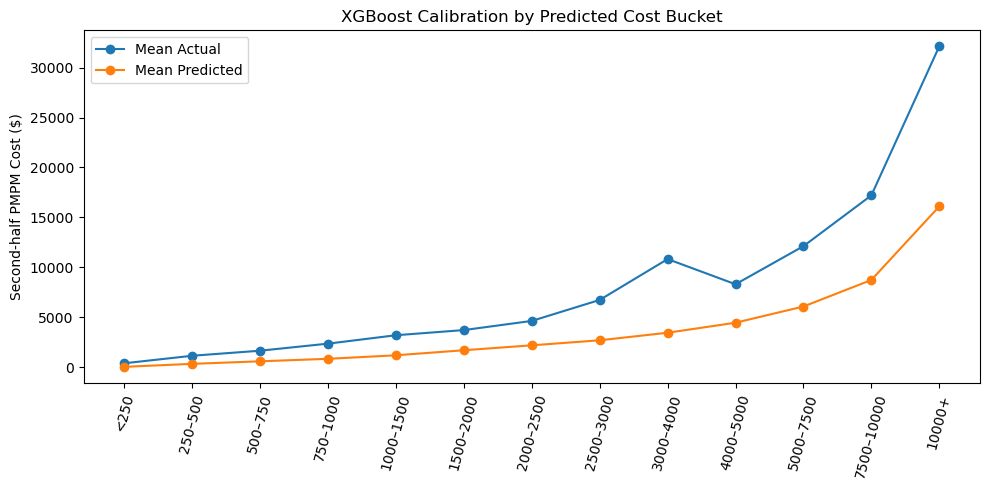

In [43]:
plt.figure(figsize=(10, 5))
plt.plot(
    xgb_group_table["pred_group"].astype(str),
    xgb_group_table["mean_actual_cost"],
    marker="o",
    label="Mean Actual"
)
plt.plot(
    xgb_group_table["pred_group"].astype(str),
    xgb_group_table["mean_predicted_cost"],
    marker="o",
    label="Mean Predicted"
)

plt.xticks(rotation=75)
plt.ylabel("Second-half PMPM Cost ($)")
plt.title("XGBoost Calibration by Predicted Cost Bucket")
plt.legend()
plt.tight_layout()
plt.show()

## Eval

In [44]:
df_eval_xgb = df_eval_xgb.sort_values("predicted_cost", ascending=False).reset_index(drop=True)

top_n = int(np.ceil(len(df_eval_xgb) * 0.10))
top_decile = df_eval_xgb.head(top_n)

lift_share = top_decile["actual_cost"].sum() / df_eval_xgb["actual_cost"].sum()

print("Share of total second-half cost captured by top 10% predicted members:", round(lift_share, 4))

Share of total second-half cost captured by top 10% predicted members: 0.442


In [45]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "decision_tree": dt.feature_importances_,
    "random_forest": rf.feature_importances_,
    "xgb": xgb.feature_importances_,
}).sort_values("xgb", ascending=False)

importance_df

,feature,decision_tree,random_forest,xgb
9,countop_first_half,0.183089,0.156441,0.335480
11,op_cost_first_half,0.763790,0.620382,0.320009
4,chronicconditionhypertensionind,0.027135,0.017097,0.107109
5,chronicconditioncancerind,0.006474,0.007958,0.055273
16,in_top_op_ccsr_category_first_half,0.003609,0.009849,0.032498
13,days_since_last_op,0.013266,0.136750,0.027912
3,chronicconditioncrfind,0.000142,0.005623,0.023731
7,chronicconditiondiabetesind,0.000510,0.008734,0.019360
2,chronicconditionhfind,0.000336,0.003566,0.017195
0,chronicconditionasthmaind,0.001106,0.008693,0.015785


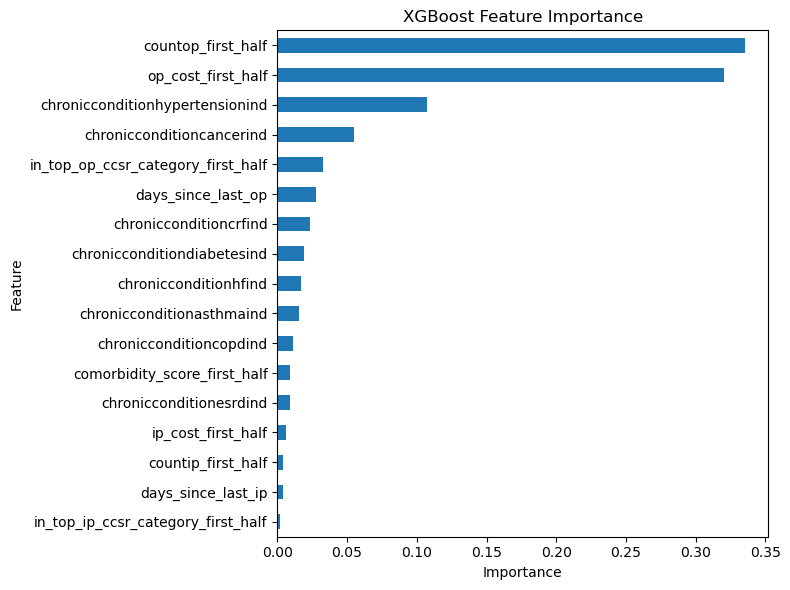

In [46]:
importance_df.sort_values("xgb", ascending=True).plot(
    kind="barh",
    x="feature",
    y="xgb",
    figsize=(8, 6),
    legend=False
)

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()